In [ ]:
#Name: Angel Vasquez
#Lab Partner: Navpreet Kloy
import numpy as np                              # numerical computing
import pandas as pd                             # data manipulation and display
from sklearn.linear_model import LogisticRegression  # logistic regression model
from sklearn.model_selection import train_test_split  # split data into train/test
from sklearn.preprocessing import StandardScaler      # standardize features
from sklearn.metrics import (                   # evaluation metrics
    accuracy_score,                             # overall accuracy
    classification_report,                      # precision, recall, f1 per class
    confusion_matrix                            # matrix of correct/incorrect predictions
)

In [ ]:
df = pd.read_csv("Dry_Bean_Dataset.csv")        # load the CSV file

# Separate features (X) and target (y)
X = df.drop(columns=["Class"])                  # all columns except Class
y = df["Class"]                                 # the bean variety labels

# Store class names for display
class_names = sorted(y.unique())                # 7 bean variety names

# Display basic information
print("=" * 60)
print("DRY BEAN DATASET OVERVIEW")
print("=" * 60)
print(f"Number of samples:  {X.shape[0]}")      # 13,611 beans total
print(f"Number of features: {X.shape[1]}")      # 16 shape measurements
print(f"Feature names:\n  {list(X.columns)}")
print(f"\nClass names: {class_names}")
print(f"\nClass distribution:")
for name in class_names:
    count = (y == name).sum()
    print(f"  {name}: {count} samples ({count/len(y)*100:.1f}%)")

DRY BEAN DATASET OVERVIEW
Number of samples:  13611
Number of features: 16
Feature names:
  ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']

Class names: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']

Class distribution:
  BARBUNYA: 1322 samples (9.7%)
  BOMBAY: 522 samples (3.8%)
  CALI: 1630 samples (12.0%)
  DERMASON: 3546 samples (26.1%)
  HOROZ: 1928 samples (14.2%)
  SEKER: 2027 samples (14.9%)
  SIRA: 2636 samples (19.4%)


In [ ]:
# Preview the first 5 rows
print("First 5 rows of the dataset:")
display(X.head())

First 5 rows of the dataset:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166


In [ ]:
display(X.describe().round(2))

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.0,13611.00,13611.00
mean,53048.28,855.28,320.14,202.27,1.58,0.75,53768.20,253.06,0.75,0.99,0.87,0.80,0.01,0.0,0.64,1.00
std,29324.10,214.29,85.69,44.97,0.25,0.09,29774.92,59.18,0.05,0.00,0.06,0.06,0.00,0.0,0.10,0.00
min,20420.00,524.74,183.60,122.51,1.02,0.22,20684.00,161.24,0.56,0.92,0.49,0.64,0.00,0.0,0.41,0.95
25%,36328.00,703.52,253.30,175.85,1.43,0.72,36714.50,215.07,0.72,0.99,0.83,0.76,0.01,0.0,0.58,0.99
50%,44652.00,794.94,296.88,192.43,1.55,0.76,45178.00,238.44,0.76,0.99,0.88,0.80,0.01,0.0,0.64,1.00
75%,61332.00,977.21,376.50,217.03,1.71,0.81,62294.00,279.45,0.79,0.99,0.92,0.83,0.01,0.0,0.70,1.00
max,254616.00,1985.37,738.86,460.20,2.43,0.91,263261.00,569.37,0.87,0.99,0.99,0.99,0.01,0.0,0.97,1.00


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                                       # features and target
    test_size=0.3,                              # 30% for testing
    random_state=42,                            # set seed for reproducibility
    stratify=y                                  # maintain class proportions
)

print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")

TRAIN/TEST SPLIT
Training set size: 9527 samples
Testing set size:  4084 samples


In [ ]:
le = StandardScaler()                       # create scaler object
X_train_scaled = le.fit_transform(X_train)  # fit on train + transform
X_test_scaled  = le.transform(X_test)       # transform test (NO fit!)

print(f"Before scaling — Area mean: {X_train['Area'].mean():.2f}")
print(f"After scaling  — Area mean: {X_train_scaled[:, 0].mean():.6f}")
print("(Should be approximately 0 after standardization)")

Before scaling — Area mean: 52969.30
After scaling  — Area mean: -0.000000
(Should be approximately 0 after standardization)


In [ ]:
model = LogisticRegression(
    solver='lbfgs',                             # L-BFGS optimization algorithm
    max_iter=1000,                              # allow enough iterations for 7 classes
    C=1.0,                                      # regularization parameter
    random_state=42                             # reproducibility
)
model.fit(X_train_scaled, y_train)              # train the model

print("=" * 60)
print("MODEL TRAINING COMPLETE")
print("=" * 60)
print(f"Number of iterations used: {model.n_iter_[0]}")
print(f"Coefficients shape: {model.coef_.shape}")   # (7 classes × 16 features)
print("(One row of coefficients per class)")

MODEL TRAINING COMPLETE
Number of iterations used: 81
Coefficients shape: (7, 16)
(One row of coefficients per class)


In [ ]:
y_pred  = model.predict(X_test_scaled)          # predicted class labels
y_proba = model.predict_proba(X_test_scaled)    # probability for each class

print("=" * 60)
print("PREDICTIONS (First 5 Test Samples)")
print("=" * 60)
for i in range(5):
    actual    = y_test.iloc[i]
    predicted = y_pred[i]
    print(f"\n  Sample {i+1}:")
    print(f"    Actual    = {actual}")
    print(f"    Predicted = {predicted}")
    print(f"    Probabilities:")
    for cls, prob in zip(model.classes_, y_proba[i]):
        marker = " ← predicted" if cls == predicted else ""
        print(f"      {cls:<12}: {prob:.4f}{marker}")

PREDICTIONS (First 5 Test Samples)

  Sample 1:
    Actual    = SEKER
    Predicted = SEKER
    Probabilities:
      BARBUNYA    : 0.0001
      BOMBAY      : 0.0000
      CALI        : 0.0000
      DERMASON    : 0.0000
      HOROZ       : 0.0000
      SEKER       : 0.9999 ← predicted
      SIRA        : 0.0000

  Sample 2:
    Actual    = SEKER
    Predicted = SEKER
    Probabilities:
      BARBUNYA    : 0.0005
      BOMBAY      : 0.0000
      CALI        : 0.0000
      DERMASON    : 0.1862
      HOROZ       : 0.0000
      SEKER       : 0.5795 ← predicted
      SIRA        : 0.2337

  Sample 3:
    Actual    = DERMASON
    Predicted = SEKER
    Probabilities:
      BARBUNYA    : 0.0007
      BOMBAY      : 0.0000
      CALI        : 0.0001
      DERMASON    : 0.1325
      HOROZ       : 0.0000
      SEKER       : 0.5280 ← predicted
      SIRA        : 0.3388

  Sample 4:
    Actual    = CALI
    Predicted = CALI
    Probabilities:
      BARBUNYA    : 0.0310
      BOMBAY      : 0.0009
   

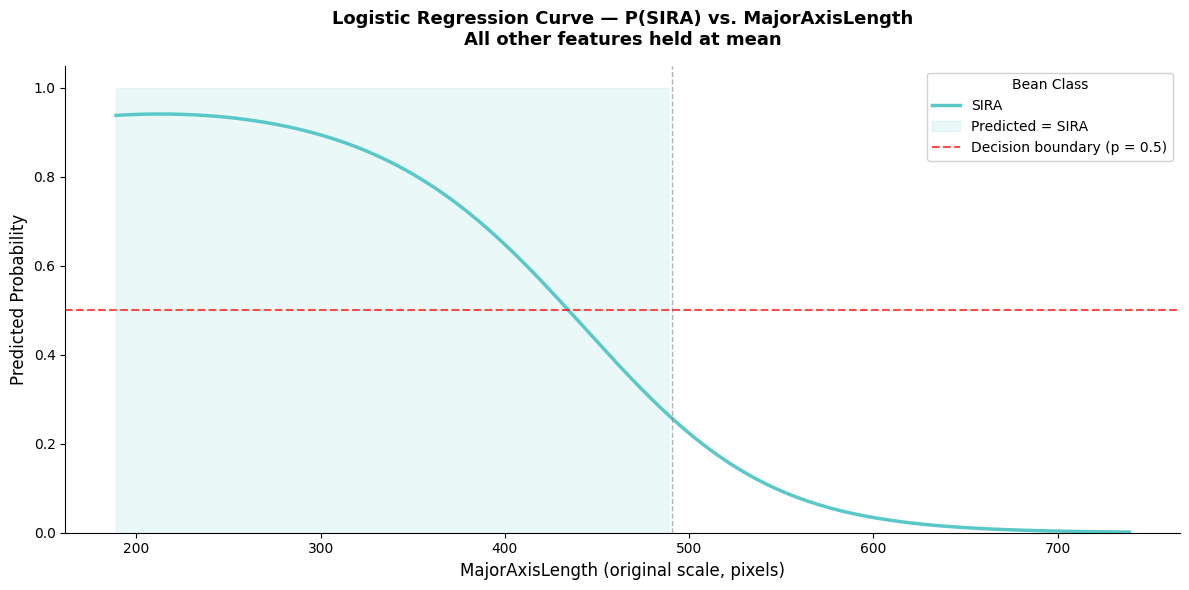

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

feature_name = 'MajorAxisLength'
feature_idx  = list(X.columns).index(feature_name)

feature_vals = np.linspace(X_test_scaled[:, feature_idx].min(),
                           X_test_scaled[:, feature_idx].max(), 300)

X_line = np.zeros((300, X_test_scaled.shape[1]))
X_line[:, feature_idx] = feature_vals

proba_line = model.predict_proba(X_line)

feature_vals_original = (feature_vals * le.scale_[feature_idx]
                         + le.mean_[feature_idx])

fig, ax = plt.subplots(figsize=(12, 6))

sira_idx = list(model.classes_).index('SIRA')
ax.plot(feature_vals_original, proba_line[:, sira_idx],
        color='#5BC8C8', linewidth=2.5, label='SIRA')

# Shade where SIRA is the predicted class
predicted_class_idx = np.argmax(proba_line, axis=1)
sira_mask = predicted_class_idx == sira_idx
if sira_mask.any():
    ax.fill_between(feature_vals_original, 0, 1,
                    where=sira_mask, alpha=0.12,
                    color='#5BC8C8', label='Predicted = SIRA')

# Decision boundary lines where SIRA region starts/ends
for x in range(1, len(predicted_class_idx)):
    if (predicted_class_idx[x] == sira_idx) != (predicted_class_idx[x-1] == sira_idx):
        ax.axvline(feature_vals_original[x], color='gray',
                   linestyle='--', linewidth=1, alpha=0.6)

# 0.5 decision boundary
ax.axhline(0.5, color='red', linestyle='--',
           linewidth=1.5, alpha=0.7, label='Decision boundary (p = 0.5)')

ax.set_xlabel(f'{feature_name} (original scale, pixels)', fontsize=12)
ax.set_ylabel('Predicted Probability', fontsize=12)
ax.set_title(f'Logistic Regression Curve — P(SIRA) vs. {feature_name}\n'
             f'All other features held at mean',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, 1.05)
ax.legend(title='Bean Class', fontsize=10, title_fontsize=10,
          loc='upper right', framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Overall Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

MODEL EVALUATION
Overall Accuracy: 0.9219 (92.2%)


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

print("Confusion Matrix:")
header = "".join(f"{name:>12}" for name in model.classes_)
print(f"{'':>16}{header}")
for i, name in enumerate(model.classes_):
    row = "".join(f"{val:>12}" for val in cm[i])
    print(f"  Actual {name:<10}{row}")

Confusion Matrix:
                    BARBUNYA      BOMBAY        CALI    DERMASON       HOROZ       SEKER        SIRA
  Actual BARBUNYA           358           0          20           0           2           8           9
  Actual BOMBAY               0         157           0           0           0           0           0
  Actual CALI                14           0         461           0           8           2           4
  Actual DERMASON             0           0           0         962           0          21          81
  Actual HOROZ                2           0           7           6         555           0           8
  Actual SEKER                2           0           0           8           0         577          21
  Actual SIRA                 0           0           3          65          14          14         695


In [ ]:
# Classification Report
print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=model.classes_
))

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.90      0.93       397
      BOMBAY       1.00      1.00      1.00       157
        CALI       0.94      0.94      0.94       489
    DERMASON       0.92      0.90      0.91      1064
       HOROZ       0.96      0.96      0.96       578
       SEKER       0.93      0.95      0.94       608
        SIRA       0.85      0.88      0.86       791

    accuracy                           0.92      4084
   macro avg       0.94      0.93      0.93      4084
weighted avg       0.92      0.92      0.92      4084



In [ ]:
coef_df = pd.DataFrame(
    model.coef_,                                # coefficient matrix (7 × 16)
    columns=X.columns,                          # feature names as columns
    index=model.classes_                        # class names as rows
)

print("=" * 60)
print("FEATURE IMPORTANCE (Top 3 per class)")
print("=" * 60)
for class_name in model.classes_:
    top_features = coef_df.loc[class_name].abs().nlargest(3)
    print(f"\n  {class_name}:")
    for feat, val in top_features.items():
        actual_val = coef_df.loc[class_name, feat]
        direction  = "↑ increases" if actual_val > 0 else "↓ decreases"
        print(f"    {feat}: {actual_val:.3f} ({direction} probability)")

print("\n" + "=" * 60)
print("Dry Bean classification complete.")
print("=" * 60)

FEATURE IMPORTANCE (Top 3 per class)

  BARBUNYA:
    ShapeFactor4: 1.945 (↑ increases probability)
    ShapeFactor2: -1.852 (↓ decreases probability)
    MinorAxisLength: 1.824 (↑ increases probability)

  BOMBAY:
    ConvexArea: 2.235 (↑ increases probability)
    Area: 2.231 (↑ increases probability)
    MinorAxisLength: 1.798 (↑ increases probability)

  CALI:
    ShapeFactor1: -2.665 (↓ decreases probability)
    roundness: 1.804 (↑ increases probability)
    ShapeFactor2: -1.594 (↓ decreases probability)

  DERMASON:
    ShapeFactor1: 3.137 (↑ increases probability)
    MajorAxisLength: -2.227 (↓ decreases probability)
    EquivDiameter: -2.222 (↓ decreases probability)

  HOROZ:
    ShapeFactor1: 3.001 (↑ increases probability)
    AspectRation: 2.784 (↑ increases probability)
    ShapeFactor4: -1.948 (↓ decreases probability)

  SEKER:
    ShapeFactor2: 2.464 (↑ increases probability)
    Eccentricity: -2.154 (↓ decreases probability)
    ShapeFactor4: 2.128 (↑ increases probab